In [ ]:
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np #linear algebra


In [ ]:
cancer_data = pd.read_csv("cancer.csv")

In [ ]:
cancer_data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
# delete colums that are not needed
cancer_data = cancer_data.drop(['Unnamed: 32', 'id',"radius_se","texture_se", "perimeter_se","area_se","smoothness_se","compactness_se","concavity_se","concave points_se","symmetry_se",
"fractal_dimension_se","radius_worst","texture_worst","perimeter_worst","area_worst","smoothness_worst","compactness_worst","concavity_worst","concave points_worst","symmetry_worst",
"fractal_dimension_worst"], axis=1)

In [ ]:
cancer_data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883


In [ ]:
print("Shape:", cancer_data.shape)
print("Columns:", cancer_data.columns.tolist())

Shape: (569, 11)
Columns: ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']


In [ ]:
#check for missing values

In [ ]:
#check for duplicate values
cancer_data.duplicated().sum()

np.int64(0)

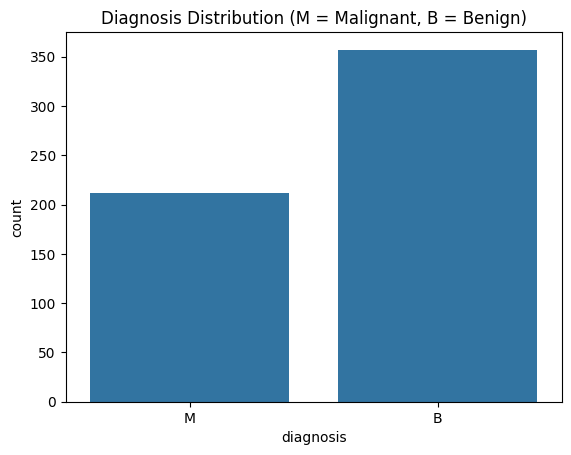

In [ ]:
#Check the distribution of diagnoses:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='diagnosis', data=cancer_data)
plt.title("Diagnosis Distribution (M = Malignant, B = Benign)")
plt.show()

cancer_data['diagnosis'] = cancer_data['diagnosis'].map({'M': 1, 'B': 0})

Logistic Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import preprocessing
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score

Split the data into training and testing groups (30-70)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(cancer_data.drop('diagnosis',axis=1),
                                                    cancer_data['diagnosis'], test_size=0.30)

In [ ]:
scaler = preprocessing.StandardScaler().fit(X_train)

In [ ]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

logmodel = LogisticRegression()
logmodel.fit(X_train_scaled,y_train)

LogisticRegression()

The predictions for the model:

In [ ]:
predictions = logmodel.predict(X_test_scaled)

Metrics for logistic regression


In [ ]:
print(classification_report(y_test,predictions))
print(confusion_matrix(y_test,predictions))
print(accuracy_score(y_test, predictions))

              precision    recall  f1-score   support

           0       0.92      0.99      0.96        97
           1       0.99      0.89      0.94        74

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.95       171
weighted avg       0.95      0.95      0.95       171

[[96  1]
 [ 8 66]]
0.9473684210526315


In [ ]:
print(confusion_matrix(y_test,predictions))

[[96  1]
 [ 8 66]]


In [ ]:
print(accuracy_score(y_test, predictions))

0.9473684210526315


In [ ]:
#Adjust Classification Threshold

probs = logmodel.predict_proba(X_test_scaled)[:, 1]
custom_preds = (probs > 0.4).astype(int)  # Try lowering from 0.5 to 0.4
print(confusion_matrix(y_test, custom_preds))
print(classification_report(y_test, custom_preds))

[[93  4]
 [ 6 68]]
              precision    recall  f1-score   support

           0       0.94      0.96      0.95        97
           1       0.94      0.92      0.93        74

    accuracy                           0.94       171
   macro avg       0.94      0.94      0.94       171
weighted avg       0.94      0.94      0.94       171



In [ ]:
#Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

print(confusion_matrix(y_test, rf_preds))
print(accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

[[92  5]
 [ 6 68]]
0.935672514619883
              precision    recall  f1-score   support

           0       0.94      0.95      0.94        97
           1       0.93      0.92      0.93        74

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



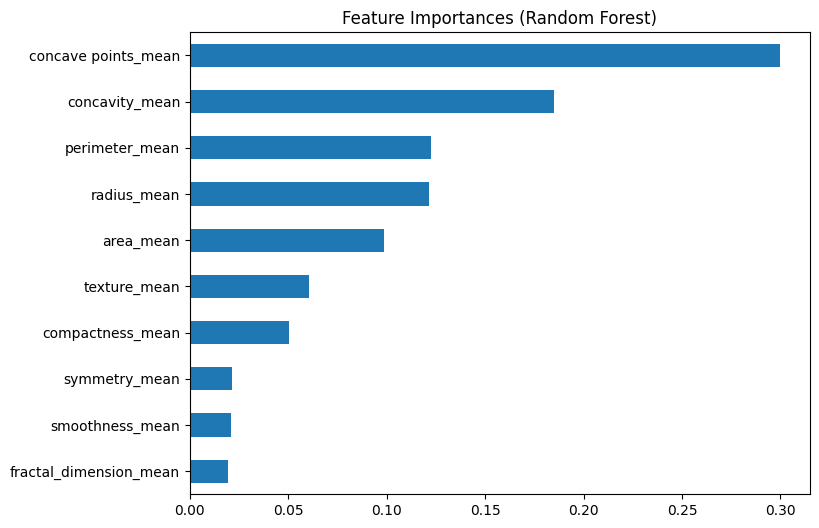

In [ ]:
#Visualize Feature Importance

importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importances (Random Forest)")
plt.show()

In [ ]:
predictions = logmodel.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Classification Report:")
print(classification_report(y_test, predictions))

print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))

print("Accuracy Score:")
print(accuracy_score(y_test, predictions))

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96        97
           1       0.99      0.89      0.94        74

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.95       171
weighted avg       0.95      0.95      0.95       171

Confusion Matrix:
[[96  1]
 [ 8 66]]
Accuracy Score:
0.9473684210526315


In [ ]:
#random forest classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict
rf_predictions = rf_model.predict(X_test_scaled)

# Evaluate
print("Classification Report:")
print(classification_report(y_test, rf_predictions))

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))

print("Accuracy Score:")
print(accuracy_score(y_test, rf_predictions))


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94        97
           1       0.93      0.92      0.93        74

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171

Confusion Matrix:
[[92  5]
 [ 6 68]]
Accuracy Score:
0.935672514619883


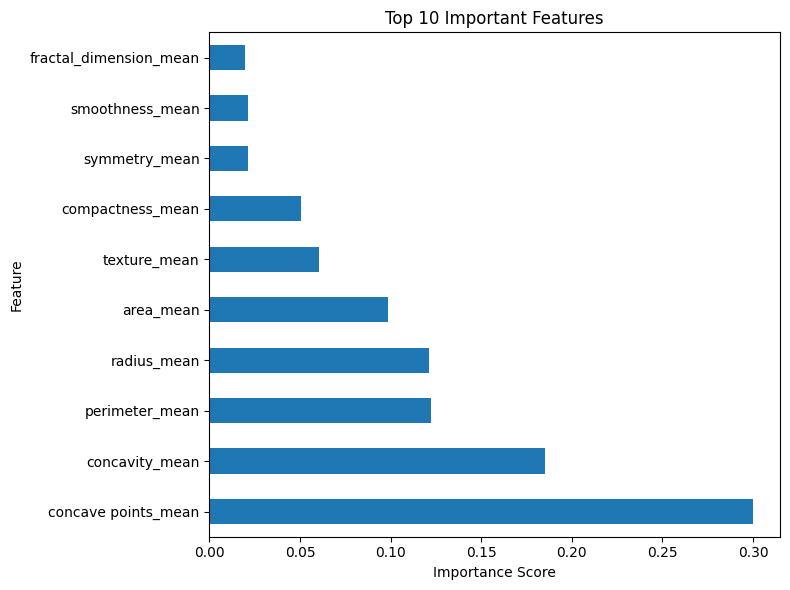

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Plot feature importances
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances.nlargest(10).plot(kind='barh', figsize=(8,6))
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

SVM (Support Vector Machine) Algorithm

In [ ]:
from sklearn.svm import SVC

In [ ]:
model = SVC()
model.fit(X_train_scaled,y_train)

SVC()

In [ ]:
svm_predictions = model.predict(X_test_scaled)

In [ ]:
print(confusion_matrix(y_test,svm_predictions))
print("--------------------------------")
print(classification_report(y_test,svm_predictions))
print("--------------------------------")
print(accuracy_score(y_test, svm_predictions))

[[95  2]
 [ 7 67]]
--------------------------------
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        97
           1       0.97      0.91      0.94        74

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.95       171
weighted avg       0.95      0.95      0.95       171

--------------------------------
0.9473684210526315


In [ ]:
#SVM - Support Vector Machine

from sklearn.svm import SVC

svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train_scaled, y_train)
svm_preds = svm_model.predict(X_test_scaled)
print("SVM Accuracy:", accuracy_score(y_test, svm_preds))

SVM Accuracy: 0.9239766081871345


In [ ]:
#Model Comparison Table
#Make a DataFrame comparing precision, recall, f1, and accuracy across models.

import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }

results = {
    "Logistic Regression": get_metrics(y_test, predictions),
    "Random Forest": get_metrics(y_test, rf_predictions),
    "SVM": get_metrics(y_test, svm_preds)
}

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.947368,0.985075,0.891892,0.936170
Random Forest,0.935673,0.931507,0.918919,0.925170
SVM,0.923977,0.955224,0.864865,0.907801
